In [1]:
#

In [2]:
import xml.etree.ElementTree as ET
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from vmatplot.bandstructure import *
from vmatplot.algorithms import transpose_matrix
from vmatplot.commons import extract_fermi
from vmatplot.output import canvas_setting, color_sampling
from vmatplot.DoS import extract_dos
from vmatplot.bandgap import extract_bandgap_outcar

def plot_multi_bs(subfigures_amount, *args):
    help_info = "Usage: plot_multi_bs \n"
    # if subfigures_amount == 1:
    #     return plot_bs_single(*args)
    # elif subfigures_amount == 2:
    #     return plot_bs_double(*args)
    # elif subfigures_amount == 3:
    #     return plot_bs_triple(*args)
    # elif subfigures_amount == 4:
    #     return plot_bs_quadruple(*args)
    if subfigures_amount == 4:
        return plot_bs_quadruple(*args)
    # help information
    else:
        print(help_info)

def plot_bs_quadruple(suptitle, subtitles, tot_matters, eigen_range, legend_loc="upper right"):
    # figure Settings
    fig_setting = canvas_setting(16, 12)
    params = fig_setting[2]; plt.rcParams.update(params)
    fig, axs = plt.subplots(2, 2, figsize=fig_setting[0], dpi=fig_setting[1])
    axes_element = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    # Colors calling
    annotate_color = color_sampling("Grey")
    fermi_color = color_sampling("Violet")

    # Title
    plt.suptitle(f"Bandstructure for {suptitle}", fontsize=fig_setting[3][0], y=1.00)

    # plot data
    for subplot_index in range(4):
        ax = axes_element[subplot_index]
        ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
        ax.set_title(subtitles[subplot_index])

        matters = create_matters_bs(tot_matters[subplot_index])
        for matter in matters:
            current_label = matter[1]
            fermi = matter[2]
            if matter[0].lower() in ["monocolor"]:
                fermi = matter[2]
                for bands_index in range(0, len(matter[4])):
                    current_band = [eigenvalue - fermi for eigenvalue in matter[4][bands_index]]
                    if bands_index == 0:
                        ax.plot(matter[3], current_band, c=color_sampling(matter[5])[1], linestyle=matter[6], alpha=matter[7], label=f"Bandstructure {current_label}", zorder=4)
                    else:
                        ax.plot(matter[3], current_band, c=color_sampling(matter[5])[1], linestyle=matter[6], alpha=matter[7], zorder=4)
            elif matter[0] in ["bands"]:
                fermi = matter[2]
                for bands_index in range(0, len(matter[4])):
                    current_conduction_band = [eigenvalue - fermi for eigenvalue in matter[4][bands_index]]
                    if bands_index == 0:
                        ax.plot(matter[3], current_conduction_band, c=color_sampling(matter[6])[2], linestyle=matter[7], alpha=matter[8], label=f"Conduction bands {current_label}", zorder=4)
                    else:
                        ax.plot(matter[3], current_conduction_band, c=color_sampling(matter[6])[2], linestyle=matter[7], alpha=matter[8], zorder=4)
                for bands_index in range(0, len(matter[5])):
                    current_valence_band = [eigenvalue - fermi for eigenvalue in matter[5][bands_index]]
                    if bands_index == 0:
                        ax.plot(matter[3], current_valence_band, c=color_sampling(matter[6])[0], linestyle=matter[7], alpha=matter[8], label=f"Valence bands {current_label}", zorder=4)
                    else:
                        ax.plot(matter[3], current_valence_band, c=color_sampling(matter[6])[0], linestyle=matter[7], alpha=matter[8], zorder=4)
            kpath_start = matter[3][0]
            kpath_end = matter[3][-1]
            fermi_last = matter[2]

        # Fermi energy as a horizon line
        ax.axhline(y = 0, color=fermi_color[0], alpha=1.00, linestyle="--", zorder=2)

        # axis ranges
        ax.set_ylim(eigen_range*(-1), eigen_range)
        ax.set_xlim(kpath_start, kpath_end)

        # axis labels
        if subplot_index in [0,2]:
            ax.set_ylabel(r"Energy (eV)")
        ax.ticklabel_format(style="sci", axis="y", scilimits=(-3,3), useOffset=False, useMathText=True)

        # High symmetry lines
        high_symmetry_paths = kpoints_path(tot_matters[subplot_index][-1][2])
        high_symmetry_positions = list(high_symmetry_paths.values())

        high_symmetry_positions.append(kpath_end)
        high_symmetry_labels = list(high_symmetry_paths.keys())

        high_symmetry_labels.append(high_symmetry_labels[0])
        ax.set_xticks(high_symmetry_positions, high_symmetry_labels)
        for k_loc in high_symmetry_positions[1:-1]:
            ax.axvline(x=k_loc, color=annotate_color[1], linestyle="--", zorder=1)
        
        # legends
        if legend_loc is None:
            legend = ax.legend()
            legend.set_visible(False)
        else:
            legend = ax.legend(loc=legend_loc)
        
        # subplots label
        orderlab_shift = 0.05
        x_loc = 0+orderlab_shift*0.75
        y_loc = 1-orderlab_shift
        ax.annotate(f"{subtitles[subplot_index]}",
                    xy=(x_loc, y_loc),
                    xycoords="axes fraction",
                    fontsize=1.0 * 16,
                    ha="left", va="center",
                    bbox = {"facecolor": "white", "alpha": 0.75, "edgecolor": annotate_color[2], "linewidth": 1.5, "boxstyle": "round, pad=0.2"},
                    zorder = 5)

    plt.tight_layout()


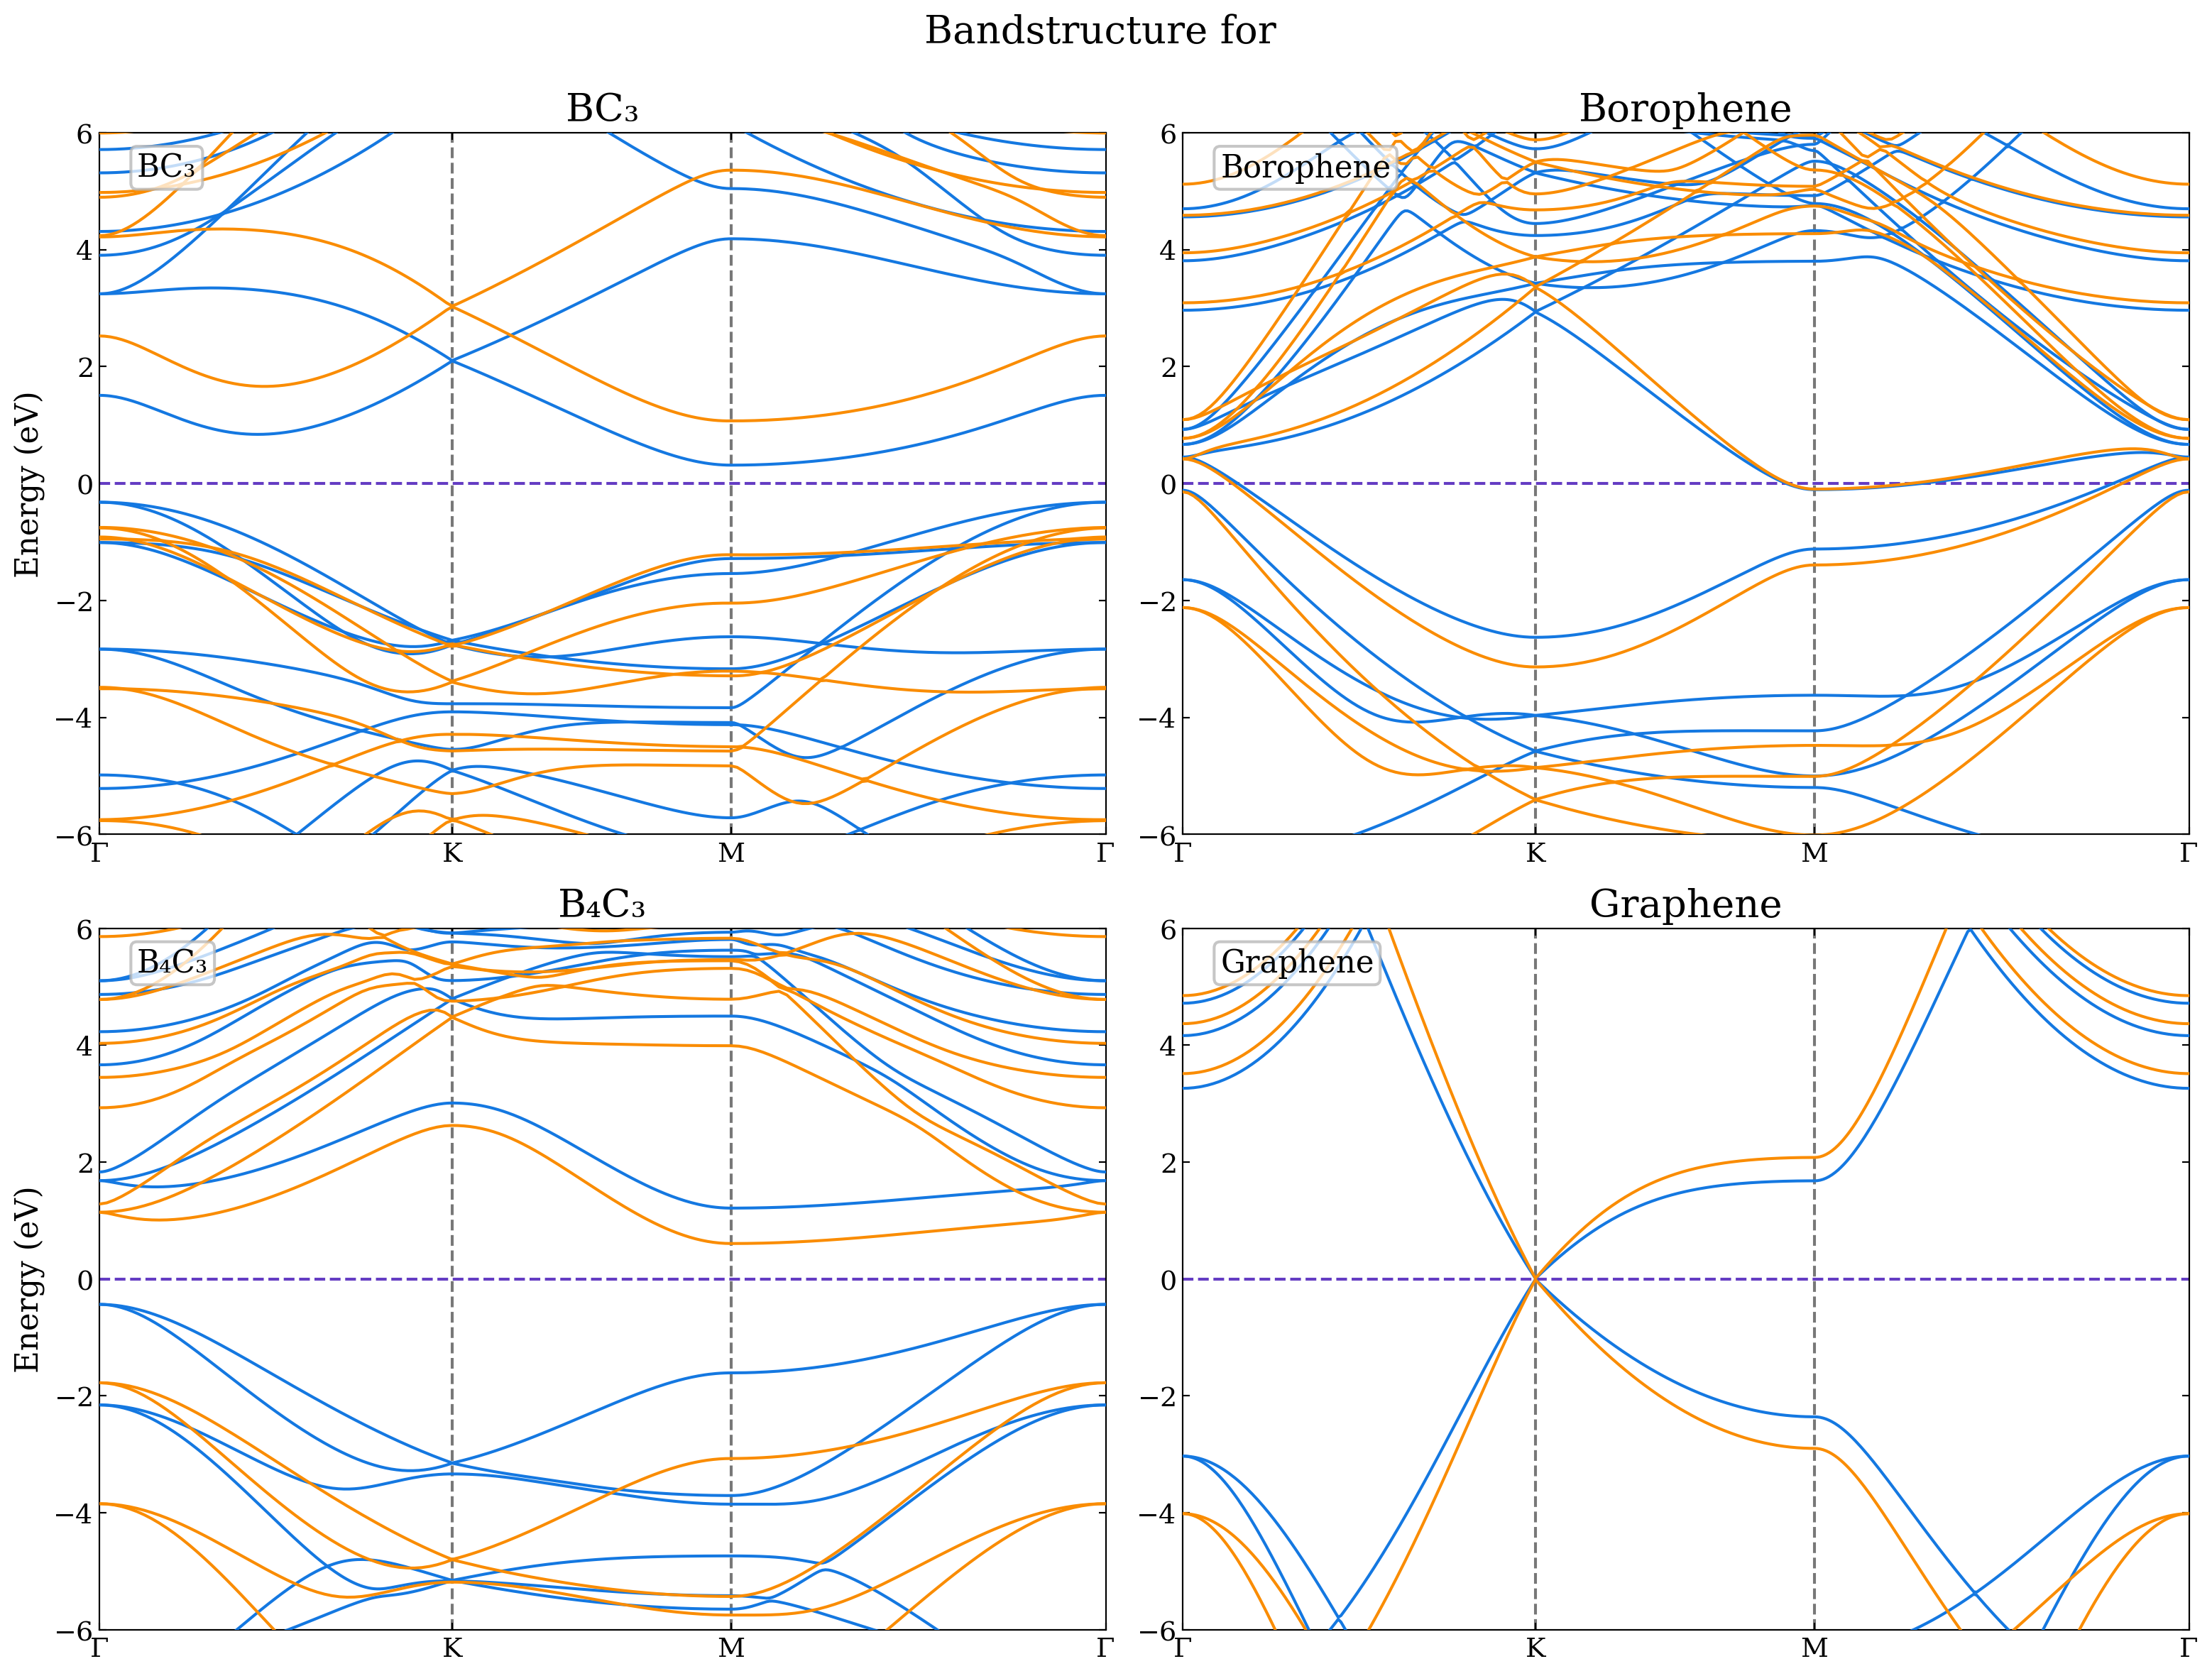

In [3]:
bs_BC3 = [["monocolor", "(PBE)", "3_Bandstructure/A_BC3_PBE", "blue"],["monocolor", "(HSE06)", "3_Bandstructure/A_BC3_HSE", "orange"]]
bs_Borophene = [["monocolor", "(PBE)", "3_Bandstructure/B_Borophene_PBE", "blue"],["monocolor", "(HSE06)", "3_Bandstructure/B_Borophene_HSE", "orange"],]
bs_B4C3 = [["monocolor", "(GGA-PBE)", "3_Bandstructure/C_B4C3_PBE", "blue"],["monocolor", "(HSE06)", "3_Bandstructure/C_B4C3_HSE", "orange"]]
bs_Graphene = [["monocolor", "(GGA-PBE)", "3_Bandstructure/D_Graphene_PBE", "blue"],["monocolor", "(HSE06)", "3_Bandstructure/D_Graphene_HSE", "orange"]]

plot_bs_quadruple("",["BC₃","Borophene","B₄C₃","Graphene"],[bs_BC3,bs_Borophene,bs_B4C3,bs_Graphene],6, None)

plt.savefig("Figures/3.31_monolayers_bandstructures.pdf")
